# Does Muon obey WeightWatcher ?


Here, I show a basic experiment comparing AdamW (🔹) vs Muon (🔸)  (the latest and greatest optimizer).   This is a simple, vibe-coded run of a 3-layer MLP on MNIST, for 500 epochs, using default settings.

Here we just look at the Muon alphas (🔸) .  The Muon  α also converge to down 2, but much, much slower 📉 than AdamW.
After 500 epochs, we have:
- FC1:  α = 2.1
- FC2:  α = 2.3
- FC3:  α = 1.9


Not bad, but not great.  And the FC1 α shows strong fluctuations ⚠︎, making it gard to get a good fit.  What’s going on?
WeightWatcher posits that the generalizing components of a layer concentrates into a low rank subspace. And, in the ideal state, this layer α converges to a universal critical exponent α=2, governed by the Wilson Exact Renormalization Group (ERG).  That is, each layer approaches a fixed point, a dynamical attractor for the optimization problem that arises in the large-N limit.

Muon actually and actively tries to prevent this❗Specifically, Muon whitens the weight matrix updates Δ𝗪 while constraining the total spectral norm (λₘₐₓ) , and I suspect this prevents  the overfitting in FC1 we see in AdamW, but it also slows down the ERG concentration effect.  But why ❓

🔥 𝗛𝗼𝘁 𝘁𝗮𝗸𝗲: the AI theory community does not grok correlated systems, and overfitting, and they confuse growth of the spectral norm (the largest eigenvalue of 𝗫 = 𝗪ᵀ𝗪), which is good (upto a point) with spuriously large elements of 𝗪 that can cause overfitting.

So where AdamW overfits, Muon underfits.  And it takes a while to converge to the ERG fixed point 🎯.  Still, Muon does very well since.  It prevents the AdamW overfitting.  And it maybe doing something else

💡 The fluctuations in the FC1 α may be a good thing.  They may represent Dragon Kings 🐲.

When weightwatcher has trouble fitting α, and we see frequent jumps between say α=2 and α>6, this usually arises because there is a spuriously large λₘₐₓ that is screwing up the power law fit.  And that can be a good thing! ⭐, as this large λₘₐₓ can accelerate convergence to the ERG fixed point.



In [ ]:
!pip install -q  weightwatcher

In [ ]:
# ======================================================
# macOS / Jupyter — FULL RESET CELL (UPDATED)
# AdamW vs torch.optim.Muon on MNIST (MLP3)
#
# Change requested:
# - For MUON only: ALWAYS treat the fix_fingers='clip_xmax' alpha for layer_id==1
#   as the TRUE alpha for fc1, and plot THAT on the main alpha plot.
#   (AdamW fc1 stays as the normal fc1 alpha from watcher.analyze()).
#
# Keeps:
# - final models: last_adamw_model, last_muon_model
# - intra=True cross alphas + distances per epoch + plots
# ======================================================

import sys, subprocess, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import weightwatcher as ww

# --- Jupyter inline (safe elsewhere) ---
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

# ----------------------------
# Device: prefer MPS on Mac
# ----------------------------
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Torch:", torch.__version__, "| Device:", device)

# ----------------------------
# Ensure torch.optim.Muon exists
# ----------------------------
if not hasattr(torch.optim, "Muon"):
    raise RuntimeError(
        "torch.optim.Muon is not available in your current PyTorch build on macOS.\n\n"
        "Install a PyTorch build that includes Muon (often nightly CPU) from Terminal:\n"
        "  python3 -m pip install --pre -U torch torchvision torchaudio "
        "--index-url https://download.pytorch.org/whl/nightly/cpu\n\n"
        "Then restart Jupyter and re-run this cell."
    )

# ----------------------------
# Repro
# ----------------------------
SEED = 1337
def set_seed(s=SEED):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

set_seed(SEED)

# ----------------------------
# Data
# ----------------------------
BATCH = 256
mnist_mean, mnist_std = (0.1307,), (0.3081,)

train_tf = transforms.Compose([
    transforms.RandomAffine(12, translate=(0.08, 0.08), scale=(0.92, 1.08), shear=8),
    transforms.ToTensor(),
    transforms.Normalize(mnist_mean, mnist_std),
])

eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mnist_mean, mnist_std),
])

train_ds      = datasets.MNIST("./data", train=True,  download=True, transform=train_tf)
train_eval_ds = datasets.MNIST("./data", train=True,  download=True, transform=eval_tf)
test_ds       = datasets.MNIST("./data", train=False, download=True, transform=eval_tf)

train_loader      = DataLoader(train_ds,      batch_size=BATCH, shuffle=True,  num_workers=0)
train_eval_loader = DataLoader(train_eval_ds, batch_size=BATCH, shuffle=False, num_workers=0)
test_loader       = DataLoader(test_ds,       batch_size=BATCH, shuffle=False, num_workers=0)

# ----------------------------
# Model (named layers)
# ----------------------------
class MLP3(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.gelu(self.fc1(x))
        x = F.gelu(self.fc2(x))
        return self.fc3(x)

# ----------------------------
# Accuracy (no grad)
# ----------------------------
@torch.no_grad()
def accuracy(model, loader):
    model.eval()
    c, n = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        p = model(x).argmax(1)
        c += (p == y).sum().item()
        n += y.numel()
    return c / n

# ----------------------------
# WeightWatcher helpers
# ----------------------------
def _alpha_from_df(df, layer_name):
    if not isinstance(df, pd.DataFrame) or len(df) == 0:
        return np.nan
    if "longname" in df.columns:
        row = df[df["longname"].astype(str).str.contains(layer_name, case=False, na=False)]
    else:
        row = df[df.get("name", pd.Series([""]*len(df))).astype(str).str.contains(layer_name, case=False, na=False)]
    if len(row) == 0 or "alpha" not in row.columns:
        return np.nan
    return float(row["alpha"].iloc[0])

def _pick_distance_col(df):
    for c in ["rand_distance", "random_distance", "D", "distance", "dist"]:
        if isinstance(df, pd.DataFrame) and c in df.columns:
            return c
    return None

def ww_metrics(model, *, kind: str):
    """
    Per epoch:
      - details = watcher.analyze()
      - layer1_clip = watcher.analyze(layers=[1], fix_fingers='clip_xmax')

    Return:
      alpha_fc1/2/3 for plotting/logging.

    IMPORTANT POLICY:
      - For kind == 'muon', alpha_fc1 is ALWAYS replaced by alpha_layer1_clip
        (i.e., treat fix_fingers alpha as the correct fc1 alpha).
      - For kind == 'adamw', alpha_fc1 is the normal fc1 alpha from details.
    """
    orig_device = next(model.parameters()).device
    model_cpu = model.to("cpu")

    watcher = ww.WeightWatcher(model_cpu)
    details = watcher.analyze()

    alpha_fc1 = _alpha_from_df(details, "fc1")
    alpha_fc2 = _alpha_from_df(details, "fc2")
    alpha_fc3 = _alpha_from_df(details, "fc3")

    alpha_layer1_clip = np.nan
    try:
        layer1_clip_df = watcher.analyze(layers=[1], fix_fingers="clip_xmax")
        if isinstance(layer1_clip_df, pd.DataFrame) and len(layer1_clip_df) > 0 and "alpha" in layer1_clip_df.columns:
            alpha_layer1_clip = float(layer1_clip_df["alpha"].iloc[0])
    except Exception:
        pass

    # Enforce: MUON fc1 alpha == clip_xmax(alpha for layer_id==1)
    if kind == "muon" and np.isfinite(alpha_layer1_clip):
        alpha_fc1 = alpha_layer1_clip

    model.to(orig_device)

    return {
        "alpha_fc1": alpha_fc1,
        "alpha_fc2": alpha_fc2,
        "alpha_fc3": alpha_fc3,
        "alpha_layer1_clip": alpha_layer1_clip,  # kept for debugging/optional plot
    }

def model_intra_cross_metrics(model):
    """
    Runs watcher.analyze(intra=True) and extracts cross alphas + distances.
    """
    orig_device = next(model.parameters()).device
    model_cpu = model.to("cpu")

    watcher = ww.WeightWatcher(model_cpu)
    intra_df = watcher.analyze(intra=True)
    dist_col = _pick_distance_col(intra_df)

    def get_pair(pair_str):
        if isinstance(intra_df, pd.DataFrame) and "name" in intra_df.columns:
            row = intra_df[intra_df["name"].astype(str).str.contains(pair_str, case=False, na=False)]
            if len(row) == 0:
                return (np.nan, np.nan)
            a = float(row["alpha"].iloc[0]) if "alpha" in row.columns else np.nan
            d = float(row[dist_col].iloc[0]) if dist_col is not None else np.nan
            return (a, d)
        return (np.nan, np.nan)

    a12, d12 = get_pair("1 X 2")
    a23, d23 = get_pair("2 X 3")

    # Fallback: if parse failed but we have 2 rows
    if (not np.isfinite(a12) or not np.isfinite(a23)) and isinstance(intra_df, pd.DataFrame) and len(intra_df) >= 2:
        if not np.isfinite(a12):
            a12 = float(intra_df["alpha"].iloc[0]) if "alpha" in intra_df.columns else a12
            d12 = float(intra_df[dist_col].iloc[0]) if dist_col is not None else d12
        if not np.isfinite(a23):
            a23 = float(intra_df["alpha"].iloc[1]) if "alpha" in intra_df.columns else a23
            d23 = float(intra_df[dist_col].iloc[1]) if dist_col is not None else d23

    model.to(orig_device)
    return {
        "intra_alpha_12": a12,
        "intra_alpha_23": a23,
        "intra_dist_12": d12,
        "intra_dist_23": d23,
    }

# ----------------------------
# KEEP final model objects (global)
# ----------------------------
last_adamw_model = None
last_muon_model  = None

# ----------------------------
# One run (AdamW or Muon)
# ----------------------------
def run(kind, epochs=20):
    global last_adamw_model, last_muon_model

    set_seed(SEED)
    model = MLP3().to(device)

    if kind == "adamw":
        opt = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-2)
        muon = None

    elif kind == "muon":
        muon = torch.optim.Muon(
            [model.fc1.weight, model.fc2.weight, model.fc3.weight],
            lr=2e-3,
            weight_decay=1e-2,
            momentum=0.95,
            nesterov=True,
            ns_steps=5,
            adjust_lr_fn="match_rms_adamw",
        )
        opt = torch.optim.AdamW(
            [model.fc1.bias, model.fc2.bias, model.fc3.bias],
            lr=2e-3,
            weight_decay=1e-2
        )
    else:
        raise ValueError(f"Unknown kind: {kind!r}")

    rows = []
    for ep in range(1, epochs + 1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            opt.zero_grad(set_to_none=True)
            if muon:
                muon.zero_grad(set_to_none=True)

            loss = F.cross_entropy(model(x), y)
            loss.backward()

            if muon:
                muon.step()
            opt.step()

        ta = accuracy(model, train_eval_loader)
        va = accuracy(model, test_loader)

        ww_row = ww_metrics(model, kind=kind)
        intra  = model_intra_cross_metrics(model)

        print(
            f"[{kind}] Epoch {ep:03d} | "
            f"train={ta*100:5.2f}% test={va*100:5.2f}% | "
            f"α(fc1)={ww_row['alpha_fc1']:.3f} α(fc2)={ww_row['alpha_fc2']:.3f} α(fc3)={ww_row['alpha_fc3']:.3f} | "
            f"(layer1_clip={ww_row['alpha_layer1_clip']:.3f}) | "
            f"α(1x2)={intra['intra_alpha_12']:.3f} α(2x3)={intra['intra_alpha_23']:.3f} | "
            f"D(1x2)={intra['intra_dist_12']:.4f} D(2x3)={intra['intra_dist_23']:.4f}"
        )

        rows.append(dict(
            optimizer=kind, epoch=ep,
            train_acc=ta, test_acc=va,
            **ww_row, **intra
        ))

    if kind == "adamw":
        last_adamw_model = model
    else:
        last_muon_model = model

    return pd.DataFrame(rows)

# ----------------------------
# Run both
# ----------------------------
EPOCHS = 100
df_adam = run("adamw", epochs=1)
df_muon = run("muon",  epochs=500)
df = pd.concat([df_adam, df_muon], ignore_index=True)

print("\nFinal models kept as:")
print("  last_adamw_model  (AdamW final epoch)")
print("  last_muon_model   (Muon final epoch)")


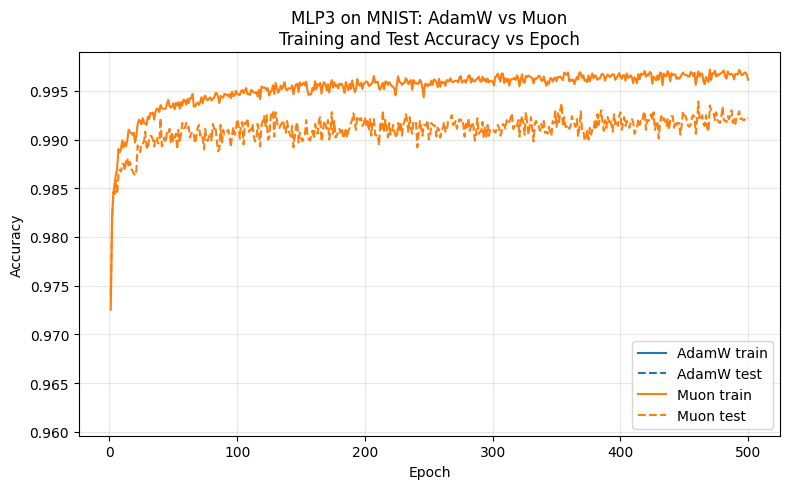

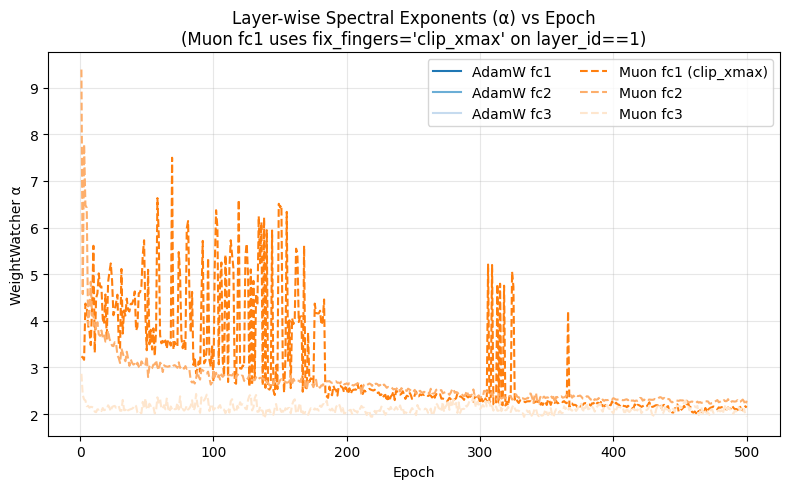

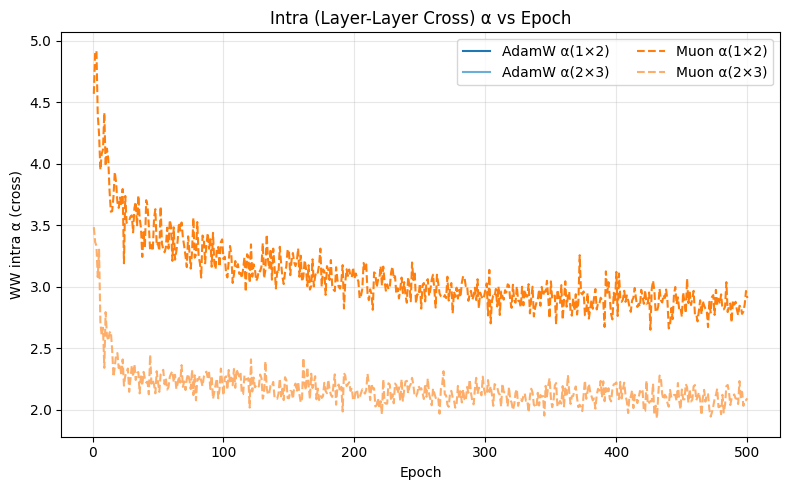

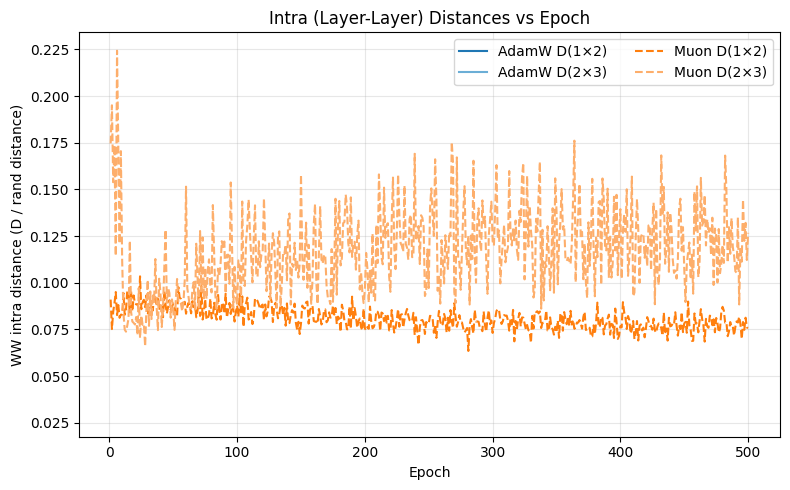


last_muon_model = MLP3
last_muon_model final test acc = 0.9922


,optimizer,epoch,train_acc,test_acc,alpha_fc1,alpha_fc2,alpha_fc3,alpha_layer1_clip,intra_alpha_12,intra_alpha_23,intra_dist_12,intra_dist_23
0,adamw,1,0.961383,0.9637,2.095938,2.245210,3.079243,2.095938,2.453061,2.327308,0.027360,0.104027
1,muon,1,0.972533,0.9742,3.236368,9.388505,2.862417,3.236368,4.569333,3.485706,0.090976,0.174664
2,muon,2,0.982100,0.9812,3.213165,4.572677,2.407115,3.213165,4.907358,3.364472,0.075194,0.195083
3,muon,3,0.984450,0.9846,3.162812,7.787005,2.314995,3.162812,4.920168,3.333872,0.084528,0.153865
4,muon,4,0.985417,0.9844,4.369697,6.480131,2.289668,4.369697,4.397754,3.080382,0.089206,0.173716
...,...,...,...,...,...,...,...,...,...,...,...,...
496,muon,496,0.996667,0.9920,2.115493,2.282748,2.121171,2.115493,2.780599,2.146211,0.078972,0.144642
497,muon,497,0.996867,0.9920,2.076301,2.310096,2.037741,2.076301,2.799736,2.033131,0.074787,0.122459
498,muon,498,0.996883,0.9922,2.134168,2.268493,2.109691,2.134168,2.857897,2.077455,0.081265,0.132098
499,muon,499,0.996600,0.9921,2.167339,2.198191,1.988123,2.167339,2.966997,2.079082,0.076025,0.112199


In [15]:

# ----------------------------
# Plot 1: Accuracy (Blue vs Orange)
# ----------------------------
df_adam = df[df["optimizer"] == "adamw"].sort_values("epoch")
df_muon = df[df["optimizer"] == "muon"].sort_values("epoch")

plt.figure(figsize=(8, 5))
plt.plot(df_adam["epoch"], df_adam["train_acc"], color="#1f77b4", linestyle="-",  label="AdamW train")
plt.plot(df_adam["epoch"], df_adam["test_acc"],  color="#1f77b4", linestyle="--", label="AdamW test")
plt.plot(df_muon["epoch"], df_muon["train_acc"], color="#ff7f0e", linestyle="-",  label="Muon train")
plt.plot(df_muon["epoch"], df_muon["test_acc"],  color="#ff7f0e", linestyle="--", label="Muon test")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP3 on MNIST: AdamW vs Muon\nTraining and Test Accuracy vs Epoch")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# Plot 2: MAIN plot — Layer-wise alphas (fc1/fc2/fc3)
# NOTE: For MUON, alpha_fc1 is already replaced by layer1_clip
# ----------------------------
adam_colors = {"fc1": "#1f77b4", "fc2": "#6baed6", "fc3": "#c6dbef"}
muon_colors = {"fc1": "#ff7f0e", "fc2": "#fdae6b", "fc3": "#fee6ce"}

plt.figure(figsize=(8, 5))
plt.plot(df_adam["epoch"], df_adam["alpha_fc1"], color=adam_colors["fc1"], linestyle="-",  label="AdamW fc1")
plt.plot(df_adam["epoch"], df_adam["alpha_fc2"], color=adam_colors["fc2"], linestyle="-",  label="AdamW fc2")
plt.plot(df_adam["epoch"], df_adam["alpha_fc3"], color=adam_colors["fc3"], linestyle="-",  label="AdamW fc3")

plt.plot(df_muon["epoch"], df_muon["alpha_fc1"], color=muon_colors["fc1"], linestyle="--", label="Muon fc1 (clip_xmax)")
plt.plot(df_muon["epoch"], df_muon["alpha_fc2"], color=muon_colors["fc2"], linestyle="--", label="Muon fc2")
plt.plot(df_muon["epoch"], df_muon["alpha_fc3"], color=muon_colors["fc3"], linestyle="--", label="Muon fc3")

plt.xlabel("Epoch")
plt.ylabel("WeightWatcher α")
plt.title("Layer-wise Spectral Exponents (α) vs Epoch\n(Muon fc1 uses fix_fingers='clip_xmax' on layer_id==1)")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

# ----------------------------
# Plot 3: Intra cross alphas per epoch
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(df_adam["epoch"], df_adam["intra_alpha_12"], color="#1f77b4", linestyle="-",  label="AdamW α(1×2)")
plt.plot(df_adam["epoch"], df_adam["intra_alpha_23"], color="#6baed6", linestyle="-",  label="AdamW α(2×3)")
plt.plot(df_muon["epoch"], df_muon["intra_alpha_12"], color="#ff7f0e", linestyle="--", label="Muon α(1×2)")
plt.plot(df_muon["epoch"], df_muon["intra_alpha_23"], color="#fdae6b", linestyle="--", label="Muon α(2×3)")
plt.xlabel("Epoch")
plt.ylabel("WW intra α (cross)")
plt.title("Intra (Layer-Layer Cross) α vs Epoch")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

# ----------------------------
# Plot 4: Intra distances per epoch
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(df_adam["epoch"], df_adam["intra_dist_12"], color="#1f77b4", linestyle="-",  label="AdamW D(1×2)")
plt.plot(df_adam["epoch"], df_adam["intra_dist_23"], color="#6baed6", linestyle="-",  label="AdamW D(2×3)")
plt.plot(df_muon["epoch"], df_muon["intra_dist_12"], color="#ff7f0e", linestyle="--", label="Muon D(1×2)")
plt.plot(df_muon["epoch"], df_muon["intra_dist_23"], color="#fdae6b", linestyle="--", label="Muon D(2×3)")
plt.xlabel("Epoch")
plt.ylabel("WW intra distance (D / rand distance)")
plt.title("Intra (Layer-Layer) Distances vs Epoch")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

print("\nlast_muon_model =", last_muon_model.__class__.__name__ if last_muon_model is not None else None)
if last_muon_model is not None:
    print("last_muon_model final test acc =", accuracy(last_muon_model, test_loader))

df

In [25]:
df[df.epoch==200]

,optimizer,epoch,train_acc,test_acc,alpha_fc1,alpha_fc2,alpha_fc3,alpha_layer1_clip,intra_alpha_12,intra_alpha_23,intra_dist_12,intra_dist_23
200,muon,200,0.995833,0.9923,2.531184,2.658294,2.017373,2.531184,3.065639,2.087891,0.075575,0.096462


In [26]:
df[df.epoch==500]

,optimizer,epoch,train_acc,test_acc,alpha_fc1,alpha_fc2,alpha_fc3,alpha_layer1_clip,intra_alpha_12,intra_alpha_23,intra_dist_12,intra_dist_23
500,muon,500,0.996133,0.9922,2.138657,2.285601,1.946493,2.138657,2.909448,2.093867,0.075798,0.126731
